In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
import matplotlib.pyplot as plt
%matplotlib inline 

import requests
from datetime import datetime, timedelta
import math
from tqdm import tqdm
from sklearn.impute import KNNImputer

In [5]:
import pandas as pd
import glob
import os

# Path where your CSV files are stored
path = "."   # current directory (adjust if needed)

# Find all CSV files ending with _gdd.csv
all_files = glob.glob(os.path.join(path, "*_gdd.csv"))

# Load and combine
dfs = []
for filename in all_files:
    df = pd.read_csv(filename)
    # Add a column with the species name (from filename)
    species = os.path.basename(filename).replace("_gdd.csv", "")
    df["species"] = species
    dfs.append(df)

# Concatenate all into one DataFrame
merged_df = pd.concat(dfs, ignore_index=True)

# Save to CSV
merged_df.to_csv("merged_gdd_dataset.csv", index=False)

print("✅ Merged dataset saved as merged_gdd_dataset.csv")


✅ Merged dataset saved as merged_gdd_dataset.csv


In [7]:
df= pd.read_csv('merged_gdd_dataset.csv')
df.head()

,observed_on,season_start,latitude,longitude,phenophase,t_base,gdd_cumulative,species
0,2025-09-16,2025-05-26,42.372560,-71.234074,fruiting,5,1848.845462,Ailanthus_altissima
1,2025-09-16,2025-05-26,42.361878,-71.255875,fruiting,5,1849.453723,Ailanthus_altissima
2,2025-09-17,2025-05-26,53.389053,-2.965071,fruiting,5,1295.690631,Ailanthus_altissima
3,2025-09-17,2025-05-26,41.130047,28.962439,fruiting,5,2155.484828,Ailanthus_altissima
4,2025-09-15,2025-05-26,47.987628,16.303219,fruiting,5,1716.335918,Ailanthus_altissima


In [8]:
df.shape

(13711, 8)

In [10]:
df.isnull().sum()

observed_on         0
season_start        0
latitude            0
longitude           0
phenophase          0
t_base              0
gdd_cumulative    631
species             0
dtype: int64

In [18]:
df.loc[df['gdd_cumulative'] == 0, 'species'].unique()


array(['Ailanthus_altissima', 'Anacamptis_morio', 'Bellis_perennis',
       'Hedera_helix', 'Malva_sylvestris', 'Robinia_pseudoacacia',
       'Trifolium_pratense', 'Veronica_persica'], dtype=object)

In [19]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)

In [21]:
median=df.gdd_cumulative.median()
median

np.float64(295.76760635376115)

In [22]:
impute_nan(df,'gdd_cumulative',median)
df.head()

,observed_on,season_start,latitude,longitude,phenophase,t_base,gdd_cumulative,species,gdd_cumulative_median
0,2025-09-16,2025-05-26,42.372560,-71.234074,fruiting,5,1848.845462,Ailanthus_altissima,1848.845462
1,2025-09-16,2025-05-26,42.361878,-71.255875,fruiting,5,1849.453723,Ailanthus_altissima,1849.453723
2,2025-09-17,2025-05-26,53.389053,-2.965071,fruiting,5,1295.690631,Ailanthus_altissima,1295.690631
3,2025-09-17,2025-05-26,41.130047,28.962439,fruiting,5,2155.484828,Ailanthus_altissima,2155.484828
4,2025-09-15,2025-05-26,47.987628,16.303219,fruiting,5,1716.335918,Ailanthus_altissima,1716.335918


In [24]:
print(df['gdd_cumulative'].std())
print(df['gdd_cumulative_median'].std())

634.2794909475347
621.5335469048932


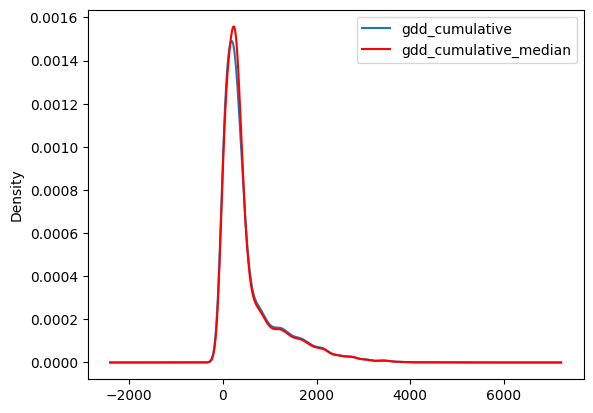

In [26]:
fig = plt.figure()
ax=fig.add_subplot(111)
df['gdd_cumulative'].plot(kind='kde',ax=ax)#kde = kernel desity estimators
df.gdd_cumulative_median.plot(kind='kde',ax=ax,color='red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [54]:
df=pd.read_csv("merged_gdd_dataset.csv")
df.head()

,observed_on,season_start,latitude,longitude,phenophase,t_base,gdd_cumulative,species
0,2025-09-16,2025-05-26,42.372560,-71.234074,fruiting,5,1848.845462,Ailanthus_altissima
1,2025-09-16,2025-05-26,42.361878,-71.255875,fruiting,5,1849.453723,Ailanthus_altissima
2,2025-09-17,2025-05-26,53.389053,-2.965071,fruiting,5,1295.690631,Ailanthus_altissima
3,2025-09-17,2025-05-26,41.130047,28.962439,fruiting,5,2155.484828,Ailanthus_altissima
4,2025-09-15,2025-05-26,47.987628,16.303219,fruiting,5,1716.335918,Ailanthus_altissima


In [56]:
df.isnull().sum()

observed_on         0
season_start        0
latitude            0
longitude           0
phenophase          0
t_base              0
gdd_cumulative    631
species             0
dtype: int64

In [57]:
df['gdd_cumulative'].dropna().sample(df['gdd_cumulative'].isnull().sum(),random_state=0)

7059      548.778134
8371      290.556616
1494      140.477663
4273        0.000000
11662    3291.203239
            ...     
2310      152.457101
7276      328.708028
1468      364.406702
11946     375.683803
8053      362.020029
Name: gdd_cumulative, Length: 631, dtype: float64

In [58]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)
    df[variable+"_random"]=df[variable]
    #it will have the random sample to fill the nan value 
    random_sample = df[variable].dropna().sample(df[variable].isnull().sum(),random_state=0)
    #pandas nedds to have the same index in order to merge the dataset
    random_sample.index=df[df[variable].isnull()].index
    df.loc[df[variable].isnull(),variable+'_random']=random_sample


In [59]:
median = df.gdd_cumulative.median()

In [61]:
impute_nan(df,"gdd_cumulative",median)

In [62]:
df.head()

,observed_on,season_start,latitude,longitude,phenophase,t_base,gdd_cumulative,species,gdd_cumulative_median,gdd_cumulative_random
0,2025-09-16,2025-05-26,42.372560,-71.234074,fruiting,5,1848.845462,Ailanthus_altissima,1848.845462,1848.845462
1,2025-09-16,2025-05-26,42.361878,-71.255875,fruiting,5,1849.453723,Ailanthus_altissima,1849.453723,1849.453723
2,2025-09-17,2025-05-26,53.389053,-2.965071,fruiting,5,1295.690631,Ailanthus_altissima,1295.690631,1295.690631
3,2025-09-17,2025-05-26,41.130047,28.962439,fruiting,5,2155.484828,Ailanthus_altissima,2155.484828,2155.484828
4,2025-09-15,2025-05-26,47.987628,16.303219,fruiting,5,1716.335918,Ailanthus_altissima,1716.335918,1716.335918


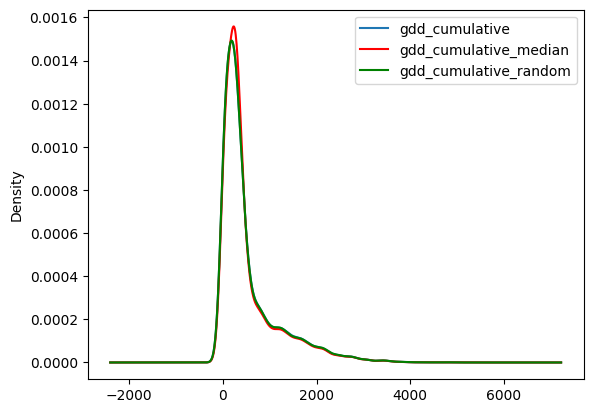

In [63]:
fig = plt.figure()
ax=fig.add_subplot(111)
df['gdd_cumulative'].plot(kind='kde',ax=ax)#kde = kernel desity estimators
df.gdd_cumulative_median.plot(kind='kde',ax=ax,color='red')
df.gdd_cumulative_random.plot(kind='kde',ax=ax,color='green')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [66]:
df.isnull().sum()

observed_on              0
season_start             0
latitude                 0
longitude                0
phenophase               0
t_base                   0
species                  0
gdd_cumulative_random    0
dtype: int64

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13711 entries, 0 to 13710
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   observed_on            13711 non-null  object 
 1   season_start           13711 non-null  object 
 2   latitude               13711 non-null  float64
 3   longitude              13711 non-null  float64
 4   phenophase             13711 non-null  object 
 5   t_base                 13711 non-null  int64  
 6   species                13711 non-null  object 
 7   gdd_cumulative_random  13711 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 857.1+ KB


In [65]:
df.drop(columns=['gdd_cumulative','gdd_cumulative_median'],inplace=True)

In [67]:
df.to_csv("final_gdd_dataset.csv", index=False)

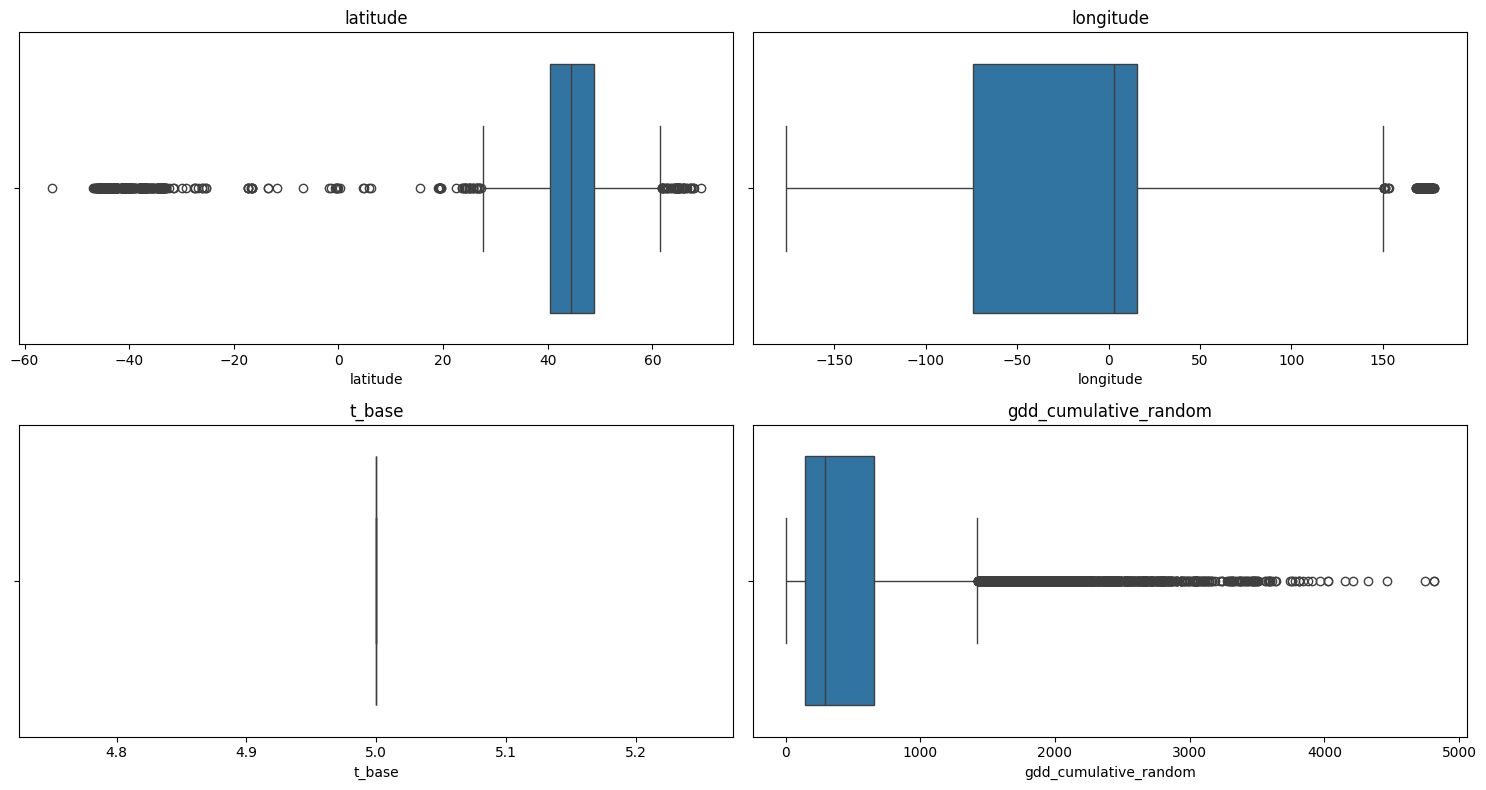

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
num_cols = df.select_dtypes(include=['float64','int64']).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, (len(num_cols)+1)//2, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [70]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary


{'latitude': 601, 'longitude': 378, 't_base': 0, 'gdd_cumulative_random': 1437}

In [73]:
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]


NameError: name 'stats' is not defined

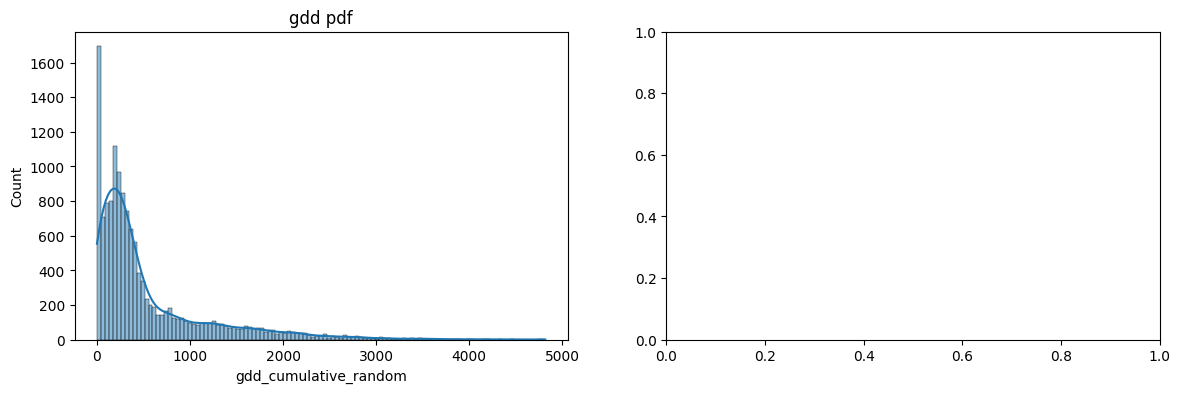

In [74]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(df['gdd_cumulative_random'],kde=True)
plt.title('gdd pdf')

plt.subplot(1,2,2)
stats.probplot(df['gdd_cumulative_random'], dist="norm",plot=plt)
plt.title('gdd QQ plot')

plt.show()

In [75]:

df['gdd_log'] = np.log1p(df['gdd_cumulative_random'])   # log(1+x) to avoid log(0)
